In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from datetime import datetime, timedelta
import datajoint as dj

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-03-04 14:12:56,673][INFO]: DataJoint is configured from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-03-04 14:12:57,040][INFO]: DataJoint 0.14.4 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [4]:
from workflow.pipeline import frame, culture, ephys, analysis, mua, probe

Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


This notebook is for determining the correct number and length of active time frames for analysis. 

Frame sessions can be created using the `CREATE_new_frame_session` notebook. 

This notebook will only need the information from the frame schema. Additionally, be sure to use the maximum number of frames you believe could be used. This notebook will analyze the firing rates as a function of the number of frames and frame length. From there you can make a decision on the number of frames and frame length to use for your analysis.

Create frame sessions for the first 2 days and the last 2 days of recording to get a sense of how the firing rates change across development.

For each time region, two parameter sets will be used (4 and 5). These indicate 24 15-minute frames and 60 5-minute frames, respectively.

In [5]:
# Insert frame sessions for all organoids with paramset 4 and 5

# get unique organoid ids from culture.Experiment
organoid_ids = [organoid_id for organoid_id in np.unique(culture.Experiment.fetch("organoid_id")) if organoid_id.startswith("O")]
drug_name = "Control"
frame_param_indices = [4, 5]

frame_key_list = []
for organoid_id in organoid_ids:

    exp_key = {
        "organoid_id": organoid_id,
        "experiment_start_time": (culture.Experiment & f"organoid_id = '{organoid_id}'" & f"drug_name = '{drug_name}'").fetch1("experiment_start_time"),
    }

    boundary_start_1 = exp_key["experiment_start_time"] + timedelta(hours=1)
    boundary_end_1 = boundary_start_1 + timedelta(days=2)

    experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_end_time")
    boundary_start_2 = experiment_end_time - timedelta(days=2)
    boundary_end_2 = experiment_end_time

    for frame_param_idx in frame_param_indices:
        frame_key_list.append({
            **exp_key,
            "start_boundary": boundary_start_1,
            "end_boundary": boundary_end_1,
            "frame_param_idx": frame_param_idx
        })
        frame_key_list.append({
            **exp_key,
            "start_boundary": boundary_start_2,
            "end_boundary": boundary_end_2,
            "frame_param_idx": frame_param_idx
        })

In [6]:
frame.FrameSession.insert(frame_key_list, skip_duplicates=True)
frame.FrameSession & frame_key_list

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,5
O09,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,4
O09,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,5
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,5
O10,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,4
O10,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,5
O11,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4
O11,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,5


Investigate the number of processed sessions compared to the number of avaiable files.

In order for the frame analysis structure to be viable, the number of processed MUA sessions needs to be close to the number of available ephys files within the defined boundaries. If there are many unprocessed sessions, this could indicate a problem with the processing pipeline or that the frames are being created before processing is complete.

In [7]:
frame.FrameAnalysis & frame_key_list

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset,num_processed_sessions Number of sessions with available data within the analysis boundaries,num_available_files Number of available ephys files within the analysis boundaries
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2880,2880
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,5,2880,2880
O09,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,4,2879,2880
O09,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,5,2879,2880
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2880,2880
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,5,2880,2880
O10,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,4,2880,2880
O10,2023-05-03 17:33:00,2023-05-16 12:15:00,2023-05-18 12:15:00,5,2880,2880
O11,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,4,2880,2880
O11,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,5,2880,2880


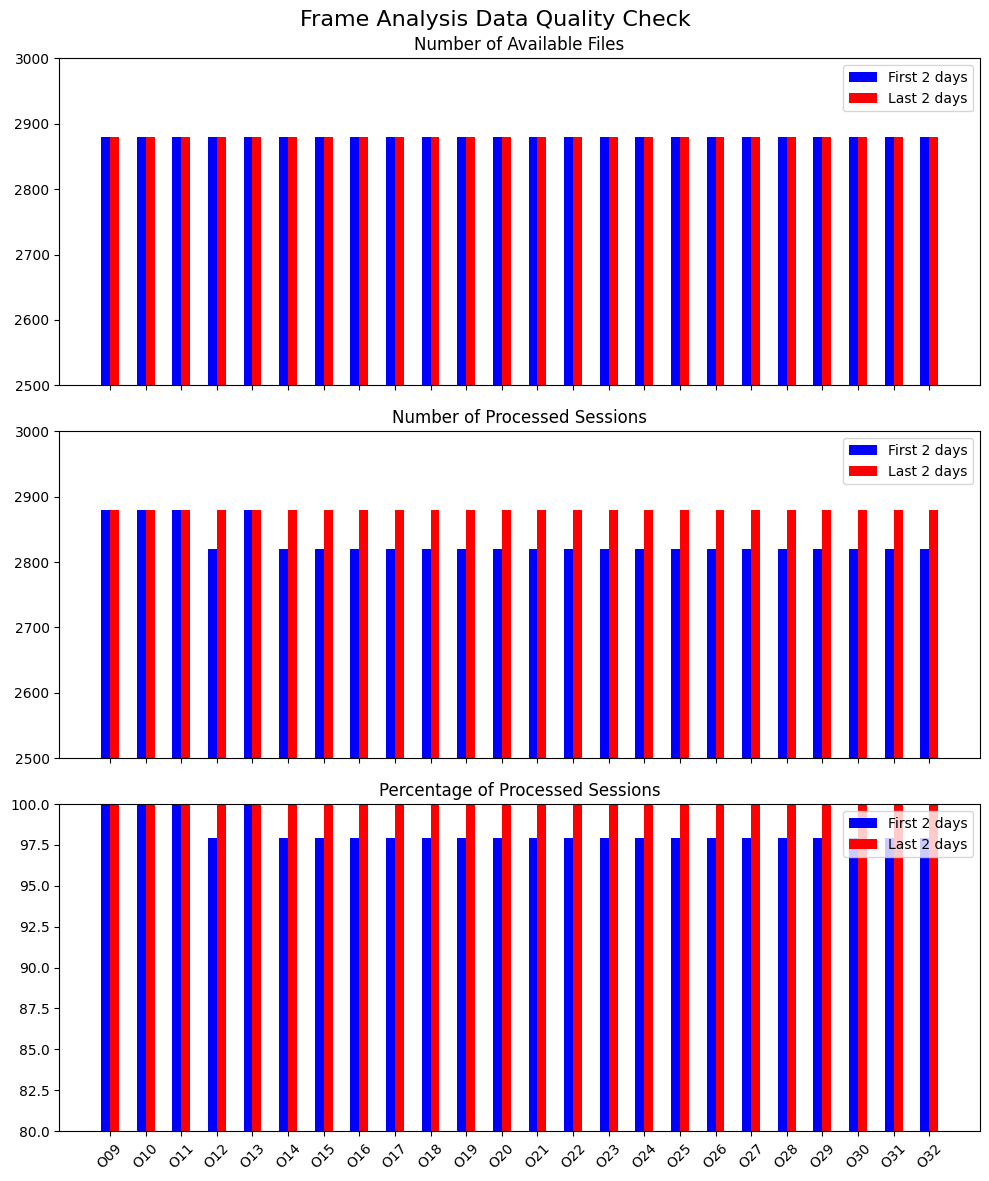

In [8]:
# Create a 3x1 figure that contains a bar plot (for each organoid) for the total number of files, the number of processed sessions, and the percentage of processed sessions. 
# For each organoid there should be 2 bars (one for each time region)

organoid_ids, start_times, num_processed_sessions, num_available_files = (frame.FrameAnalysis & frame_key_list & "frame_param_idx = 4").fetch("organoid_id", "start_boundary", "num_processed_sessions", "num_available_files")

plot_data = {}

for organoid_id in np.unique(organoid_ids):

    organoid_mask = organoid_ids == organoid_id

    plot_data[organoid_id] = {
        "num_available_files": num_available_files[organoid_mask],
        "num_processed_sessions": num_processed_sessions[organoid_mask],
        "percentage_processed": (num_processed_sessions[organoid_mask] / num_available_files[organoid_mask]) * 100
    }

# plot
fig, axes = plt.subplots(3, 1, figsize=(10, 12), tight_layout=True, sharex=True)
fig.suptitle("Frame Analysis Data Quality Check", fontsize=16)
barwidth = .25

for i, (organoid_id, data_dict) in enumerate(plot_data.items()):

    if i == 0:
        axes[0].bar([i, i+barwidth], [data_dict["num_available_files"][0], data_dict["num_available_files"][1]], width=barwidth, color = ["blue", "red"], label=["First 2 days", "Last 2 days"])
        axes[1].bar([i, i+barwidth], [data_dict["num_processed_sessions"][0], data_dict["num_processed_sessions"][1]], width=barwidth, color = ["blue", "red"], label=["First 2 days", "Last 2 days"])
        axes[2].bar([i, i+barwidth], [data_dict["percentage_processed"][0], data_dict["percentage_processed"][1]], width=barwidth, color = ["blue", "red"], label=["First 2 days", "Last 2 days"])
    else:
        axes[0].bar([i, i+barwidth], [data_dict["num_available_files"][0], data_dict["num_available_files"][1]], width=barwidth, color = ["blue", "red"])
        axes[1].bar([i, i+barwidth], [data_dict["num_processed_sessions"][0], data_dict["num_processed_sessions"][1]], width=barwidth, color = ["blue", "red"])
        axes[2].bar([i, i+barwidth], [data_dict["percentage_processed"][0], data_dict["percentage_processed"][1]], width=barwidth, color = ["blue", "red"])

axes[0].set_title("Number of Available Files")
axes[0].set_ylim([2500, 3000])
axes[0].legend()

axes[1].set_title("Number of Processed Sessions")
axes[1].set_ylim([2500, 3000])
axes[1].legend()

axes[2].set_xticks([i + barwidth/2 for i in range(len(plot_data))])
axes[2].set_xticklabels(plot_data.keys(), rotation=45)
axes[2].set_title("Percentage of Processed Sessions")
axes[2].set_ylim([80, 100])
axes[2].legend()

plt.show()

Investigate the firing rates across frames for each organoid.

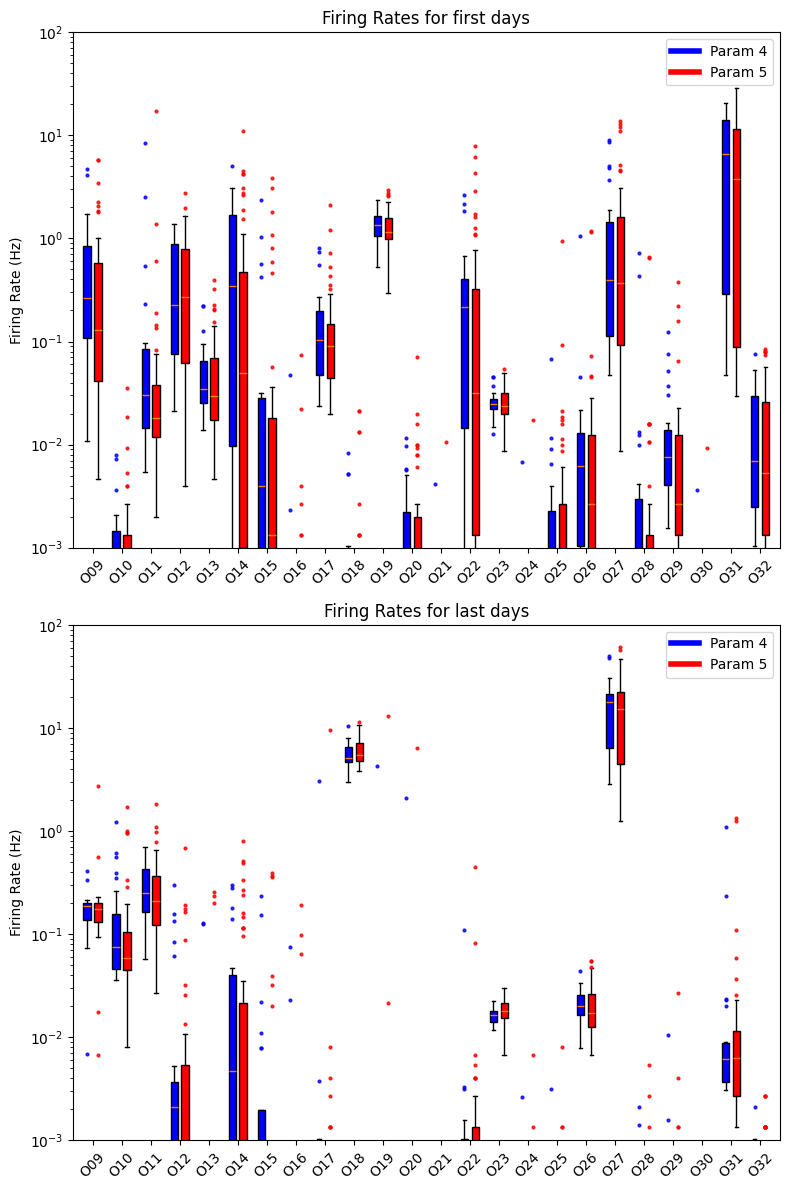

In [9]:
# For each time region (first 2 days and last 2 days) plot a box and whisker plot for each organoid (and paramset idx) showing the distribution of firing rates across all frames 
# for that organoid and time region.

organoid_ids, start_times, frame_param_indices, firing_rates = (frame.FrameAnalysis.ActiveTimeFrames & frame_key_list).fetch("organoid_id", "start_boundary", "frame_param_idx", "frame_firing_rate")

plot_dict = {
    "first days": {},
    "last days": {}
}
time_labels = ["first days", "last days"]

for organoid_id in np.unique(organoid_ids):
    organoid_mask = organoid_ids == organoid_id

    for i, start_time in enumerate(np.sort(np.unique(start_times[organoid_mask]))):
        time_mask = start_times == start_time

        plot_dict[time_labels[i]][organoid_id] = {}

        for frame_param_idx in np.unique(frame_param_indices[organoid_mask & time_mask]):
            param_mask = frame_param_indices == frame_param_idx

            firing_rate_data = firing_rates[organoid_mask & time_mask & param_mask]
            plot_dict[time_labels[i]][organoid_id][frame_param_idx] = firing_rate_data
        
# Plot
fig, axs = plt.subplots(2, 1, figsize=(8, 12), tight_layout=True)
plot_colors = {4: "blue", 5: "red"}
xticklabels = np.unique(organoid_ids)
plotwidth = 0.25

for i, (time_label, organoid_dict) in enumerate(plot_dict.items()):

    for o, (organoid_id, param_dict) in enumerate(organoid_dict.items()):

        for p, (param_idx, firing_rate_data) in enumerate(param_dict.items()):

            x = o + (p-.5)*plotwidth*1.5
            flierprops = dict(
                marker='o',          # circle point
                markersize=2,        # smaller outlier points
                markerfacecolor=plot_colors[param_idx],  # filled color
                markeredgecolor=plot_colors[param_idx],  # edge color
                alpha=0.8
            )

            axs[i].boxplot(
                firing_rate_data,
                positions=[x],
                widths=plotwidth,
                patch_artist=True,
                boxprops=dict(facecolor=plot_colors[param_idx]),
                flierprops=flierprops
            )

            
    
    axs[i].set_title(f"Firing Rates for {time_label}")
    axs[i].set_xticks(range(len(organoid_dict)))
    axs[i].set_xticklabels(xticklabels, rotation=45)
    axs[i].set_ylabel("Firing Rate (Hz)")
    axs[i].set_yscale("log" )
    axs[i].set_ylim([1e-3, 1e2])
    axs[i].legend([plt.Line2D([0], [0], color=color, lw=4) for color in plot_colors.values()], [f"Param {idx}" for idx in plot_colors.keys()])

plt.show()

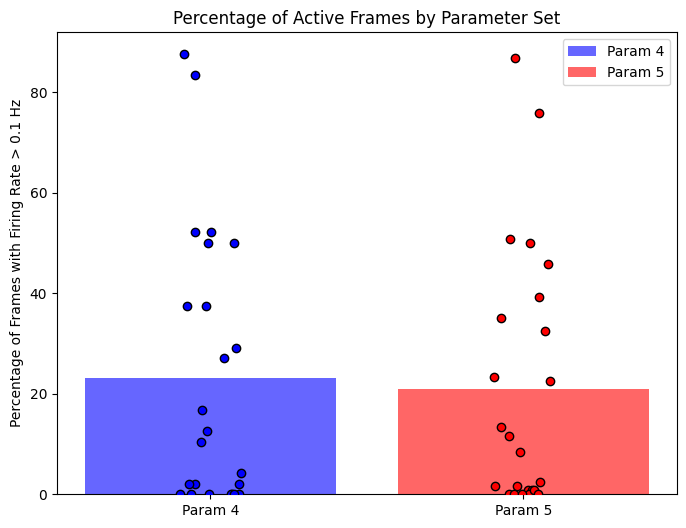

In [14]:
# Determine the perentage of frames that have a firing rate above 0.1 Hz for each organoid and param set (combined time regions)

organoid_ids, frame_param_indices, firing_rates = (frame.FrameAnalysis.ActiveTimeFrames & frame_key_list).fetch("organoid_id", "frame_param_idx", "frame_firing_rate")

plot_data = {}

for frame_param_idx in np.unique(frame_param_indices):
    plot_data[frame_param_idx] = []

    for organoid_id in np.unique(organoid_ids):

        mask = (organoid_ids == organoid_id) & (frame_param_indices == frame_param_idx)
        firing_rate_data = firing_rates[mask]

        # calculate percentage of frames with firing rate above 0.1 Hz  
        percentage_above_threshold = np.sum(firing_rate_data > 0.1) / len(firing_rate_data) * 100
        plot_data[frame_param_idx].append(percentage_above_threshold)

# Plot (bar plot with individual data points overlaid)
fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = {4: "blue", 5: "red"}

for i, (param_idx, percentages) in enumerate(plot_data.items()):
    x = i
    ax.bar(x, np.mean(percentages), color=bar_colors[param_idx], alpha=0.6, label=f"Param {param_idx}")
    ax.scatter([x + (np.random.random() - 0.5) * 0.2 for _ in range(len(percentages))], percentages, color=bar_colors[param_idx], edgecolor='k', zorder=5)
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels([f"Param {idx}" for idx in plot_data.keys()])
ax.set_ylabel("Percentage of Frames with Firing Rate > 0.1 Hz")
ax.set_title("Percentage of Active Frames by Parameter Set")
ax.legend()
plt.show()

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_19908\3633054129.py:26: RuntimeWarning:

Mean of empty slice



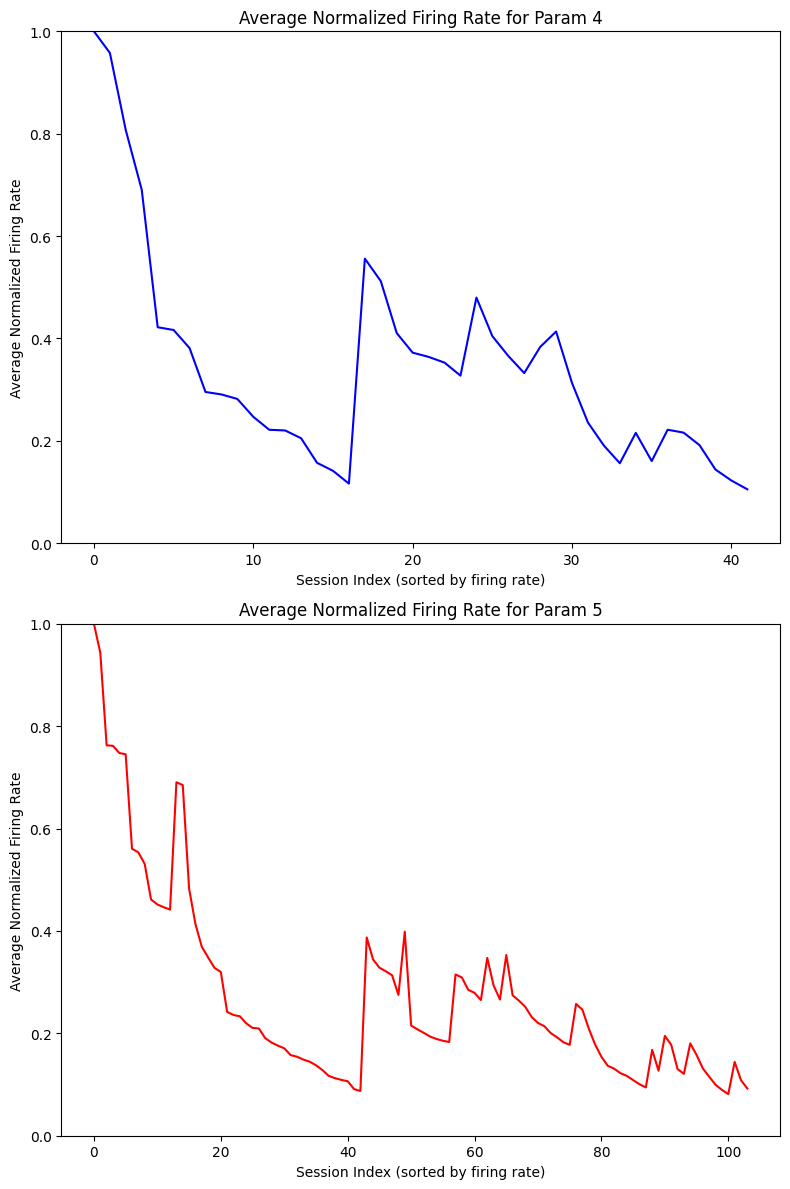

In [26]:
# Investigate how many sessions would be optimal for future analysis

organoid_ids, frame_param_indices, firing_rates = (frame.FrameAnalysis.ActiveTimeFrames & frame_key_list).fetch("organoid_id", "frame_param_idx", "frame_firing_rate")

plot_data = {}
for frame_param_idx in np.unique(frame_param_indices):
    param_mask = frame_param_indices == frame_param_idx
    plot_data[frame_param_idx] = []

    for organoid_id in np.unique(organoid_ids[param_mask]):
        organoid_mask = organoid_ids == organoid_id

        mask = param_mask & organoid_mask & (firing_rates >= 0.1)

        if np.sum(mask) < 3:
            continue
        
        normalized_firing_rates = np.sort(firing_rates[mask] / np.max(firing_rates[mask]))
        nan_pad = 1000 - len(normalized_firing_rates)
        normalized_firing_rates = np.pad(normalized_firing_rates, (0, nan_pad), constant_values=np.nan)

        plot_data[frame_param_idx].append(normalized_firing_rates)

for param_idx, data in plot_data.items():
    data = np.array(data)
    data = np.nanmean(data, axis=0)
    plot_data[param_idx] = data[~np.isnan(data)][::-1]

# Plot 
fig, axs = plt.subplots(2, 1, figsize=(8, 12), tight_layout=True)
for i, (param_idx, data) in enumerate(plot_data.items()):
    axs[i].plot(data, color=bar_colors[param_idx])
    axs[i].set_title(f"Average Normalized Firing Rate for Param {param_idx}")
    axs[i].set_xlabel("Session Index (sorted by firing rate)")
    axs[i].set_ylabel("Average Normalized Firing Rate")
    axs[i].set_ylim([0, 1])